# Experiment 2 – NMF Evaluation

Post-hoc grid search over `n_components` to justify the fixed parameters in `Experiment_2_NMF.ipynb`.

Pipeline: vectorize → fit NMF grid → coherence (c_v) + reconstruction error → penalized score → confidence distribution → LDA vs NMF comparison.

In [1]:
import importlib
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

axis2_dir = str(PROJECT_ROOT / 'notebooks' / '03_Topic_and_Insights')
if axis2_dir not in sys.path:
    sys.path.insert(0, axis2_dir)

from Data_preprocessing import Parameters_Path as config
importlib.reload(config)

INPUT_PATH   = PROJECT_ROOT / 'data' / 'processed' / 'preprocessed_input.csv'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'Experiment_2_NMF'
LDA_RESULTS  = PROJECT_ROOT / 'results' / 'Experiment_1_LDA'

tfidf_cfg = config.PARAMETERS['tfidf_vectorizer']
nmf_cfg   = config.PARAMETERS['nmf']

EVAL_N_TOPICS = [4, 6, 8, 10, 12, 16]
LAMBDA_COST   = 0.25
N_TOP_WORDS   = int(nmf_cfg['n_top_words'])
RANDOM_STATE  = int(nmf_cfg['random_state'])

In [3]:
df    = pd.read_csv(INPUT_PATH)
texts = df['text_cleaned_axis1'].astype(str).str.strip()
texts = texts[texts.ne('')]

vectorizer = TfidfVectorizer(
    max_df=tfidf_cfg['max_df'],
    min_df=tfidf_cfg['min_df'],
    max_features=tfidf_cfg['max_features'],
    stop_words=tfidf_cfg['stop_words']
)
X_tfidf       = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()
tokenized     = [t.split() for t in texts]
dictionary    = Dictionary(tokenized)

X_tfidf.shape

(8465, 1200)

## Grid Search

In [4]:
models, recon_errors = {}, {}
for k in EVAL_N_TOPICS:
    nmf = NMF(
        n_components=k,
        random_state=RANDOM_STATE,
        max_iter=nmf_cfg['max_iter']
    )
    nmf.fit(X_tfidf)
    models[k]       = nmf
    recon_errors[k] = nmf.reconstruction_err_
    print(f'n_components={k}  reconstruction_err={recon_errors[k]:.2f}')

n_components=4  reconstruction_err=86.99
n_components=6  reconstruction_err=85.15
n_components=8  reconstruction_err=83.33
n_components=10  reconstruction_err=81.59
n_components=12  reconstruction_err=80.01
n_components=16  reconstruction_err=77.14


In [6]:
rows = []
for k, nmf in models.items():
    topic_words = [
        [feature_names[i] for i in topic.argsort()[-N_TOP_WORDS:][::-1]]
        for topic in nmf.components_
    ]
    coherence = CoherenceModel(
        topics=topic_words, texts=tokenized,
        dictionary=dictionary, coherence='c_v'
    ).get_coherence()
    rows.append({'n_topics': k, 'coherence_cv': coherence, 'recon_err': recon_errors[k]})

metrics_df = pd.DataFrame(rows)
metrics_df

,n_topics,coherence_cv,recon_err
0,4,0.730680,86.988831
1,6,0.664139,85.146861
2,8,0.687545,83.332474
3,10,0.670371,81.592527
4,12,0.697202,80.007668
5,16,0.722130,77.143582


## Penalized Score

`score = coherence_norm − λ × topic_cost_norm`  
Higher is better; λ controls the complexity penalty.

In [7]:
coh = metrics_df['coherence_cv']
k_  = metrics_df['n_topics']

metrics_df['coh_norm']  = (coh - coh.min()) / (coh.max() - coh.min())
metrics_df['cost_norm'] = (k_  - k_.min())  / (k_.max()  - k_.min())
metrics_df['penalized'] = metrics_df['coh_norm'] - LAMBDA_COST * metrics_df['cost_norm']

best_k = int(metrics_df.loc[metrics_df['penalized'].idxmax(), 'n_topics'])
print(f'best n_components: {best_k}')

metrics_df.to_csv(RESULTS_DIR / 'Experiment_2_nmf_eval_metrics.csv', index=False)

best n_components: 4


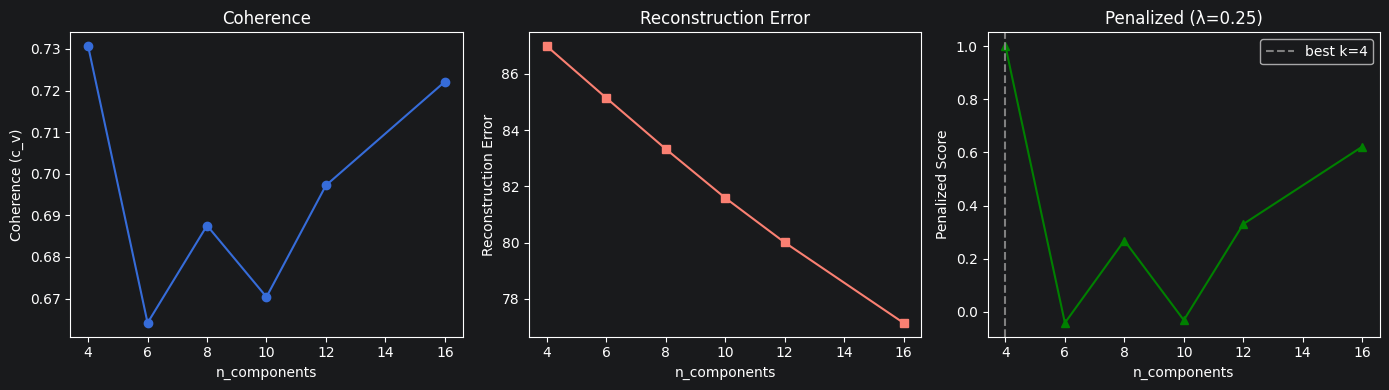

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(metrics_df['n_topics'], metrics_df['coherence_cv'], marker='o')
axes[0].set_xlabel('n_components'); axes[0].set_ylabel('Coherence (c_v)'); axes[0].set_title('Coherence')

axes[1].plot(metrics_df['n_topics'], metrics_df['recon_err'], marker='s', color='salmon')
axes[1].set_xlabel('n_components'); axes[1].set_ylabel('Reconstruction Error'); axes[1].set_title('Reconstruction Error')

axes[2].plot(metrics_df['n_topics'], metrics_df['penalized'], marker='^', color='green')
axes[2].axvline(best_k, linestyle='--', color='gray', label=f'best k={best_k}')
axes[2].set_xlabel('n_components'); axes[2].set_ylabel('Penalized Score'); axes[2].set_title(f'Penalized (λ={LAMBDA_COST})')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_2_nmf_eval_metrics.png')
plt.show()

## Confidence Distribution

Per-document dominant-topic probability from the fixed-config model output.

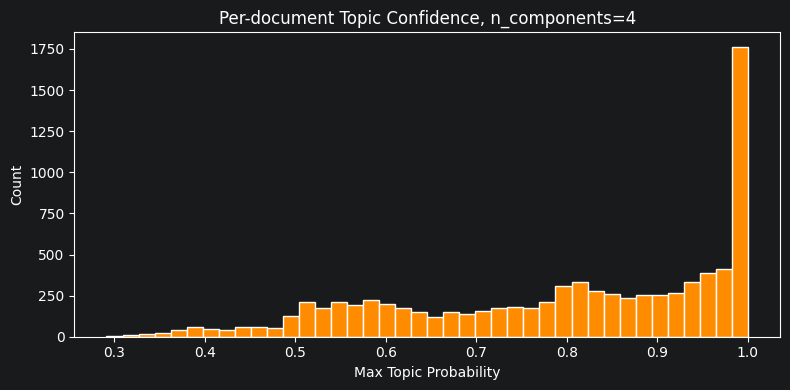

count    8465.000000
mean        0.799784
std         0.179463
min         0.291447
25%         0.651587
50%         0.835197
75%         0.967415
max         1.000000
Name: max_topic_prob, dtype: float64

In [9]:
doc_topic_df = pd.read_csv(RESULTS_DIR / 'Experiment_2_nmf_doc_topics.csv')

plt.figure(figsize=(8, 4))
plt.hist(doc_topic_df['max_topic_prob'], bins=40, color='darkorange', edgecolor='white')
plt.xlabel('Max Topic Probability')
plt.ylabel('Count')
plt.title(f'Per-document Topic Confidence, n_components={nmf_cfg["n_components"]}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_2_nmf_confidence_dist.png')
plt.show()

doc_topic_df['max_topic_prob'].describe()

## LDA vs NMF Comparison

Coherence curves and confidence distributions from both experiments side by side.

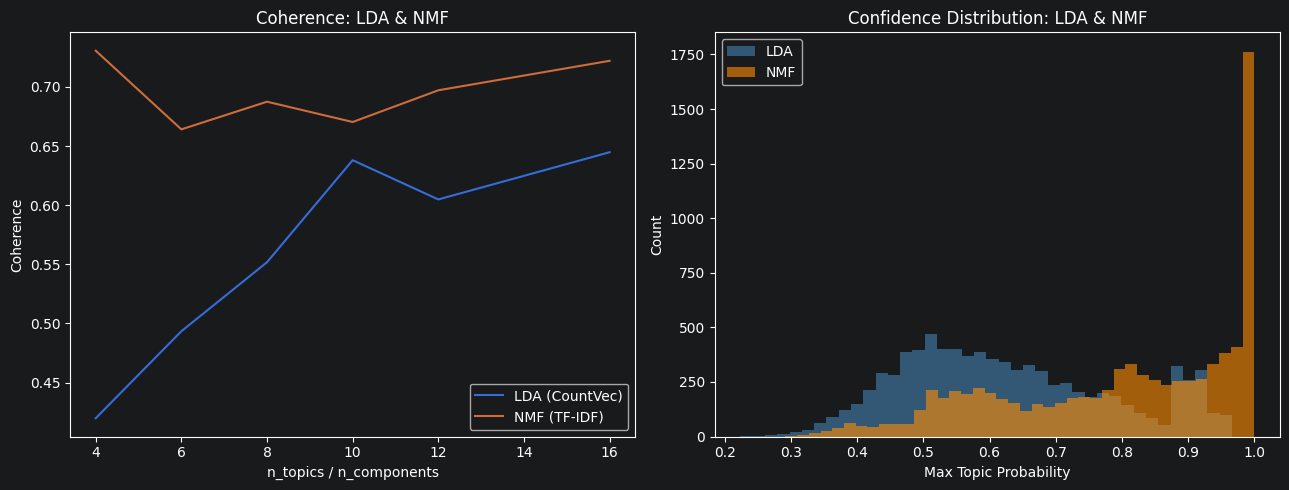

,Model,best_k,max_coherence,mean_conf for best n_components
0,LDA,10,0.644796,0.627165
1,NMF,4,0.730680,0.799784


In [10]:
lda_metrics = pd.read_csv(LDA_RESULTS / 'Experiment_1_lda_eval_metrics.csv')
nmf_metrics = metrics_df

lda_doc = pd.read_csv(LDA_RESULTS / 'Experiment_1_lda_doc_topics.csv')
nmf_doc = doc_topic_df

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coherence curves
axes[0].plot(lda_metrics['n_topics'], lda_metrics['coherence_cv'], label='LDA (CountVec)')
axes[0].plot(nmf_metrics['n_topics'], nmf_metrics['coherence_cv'], label='NMF (TF-IDF)')
axes[0].set_xlabel('n_topics / n_components')
axes[0].set_ylabel('Coherence')
axes[0].set_title('Coherence: LDA & NMF')
axes[0].legend()

# Confidence distributions
axes[1].hist(lda_doc['max_topic_prob'], bins=40, alpha=0.6, label='LDA', color='steelblue')
axes[1].hist(nmf_doc['max_topic_prob'], bins=40, alpha=0.6, label='NMF', color='darkorange')
axes[1].set_xlabel('Max Topic Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution: LDA & NMF')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_lda_nmf_comparison.png')
plt.show()

pd.DataFrame({
    'Model':        ['LDA', 'NMF'],
    'best_k':       [int(lda_metrics.loc[lda_metrics['penalized'].idxmax(), 'n_topics']), best_k],
    'max_coherence': [lda_metrics['coherence_cv'].max(), nmf_metrics['coherence_cv'].max()],
    'mean_conf for best n_components':     [lda_doc['max_topic_prob'].mean(), nmf_doc['max_topic_prob'].mean()]
})